<a href="https://colab.research.google.com/github/omgupta3128/ML-Projects/blob/main/Road_accident_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [24]:
df = pd.read_csv("traffic_accident.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (840, 14)
  Weather   Road_Type Time_of_Day  Traffic_Density  Speed_Limit  \
0   Rainy   City Road     Morning              1.0        100.0   
1   Clear  Rural Road       Night              NaN        120.0   
2   Rainy     Highway     Evening              1.0         60.0   
3   Clear   City Road   Afternoon              2.0         60.0   
4   Rainy     Highway     Morning              1.0        195.0   

   Number_of_Vehicles  Driver_Alcohol Accident_Severity      Road_Condition  \
0                 5.0             0.0               NaN                 Wet   
1                 3.0             0.0          Moderate                 Wet   
2                 4.0             0.0               Low                 Icy   
3                 3.0             0.0               Low  Under Construction   
4                11.0             0.0               Low                 Dry   

  Vehicle_Type  Driver_Age  Driver_Experience Road_Light_Condition  Accident  
0          Car    

In [26]:
df.fillna(df.mean(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_446/2159705152.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


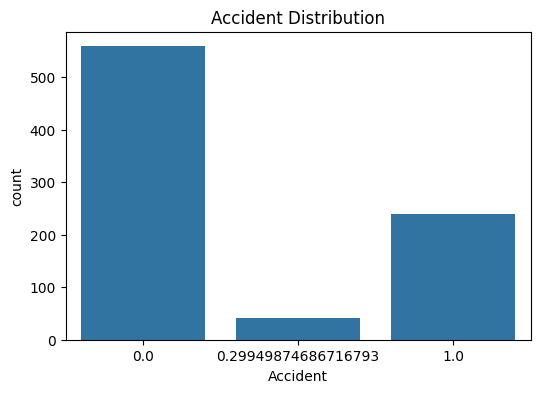

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='Accident', data=df)
plt.title("Accident Distribution")
plt.show()

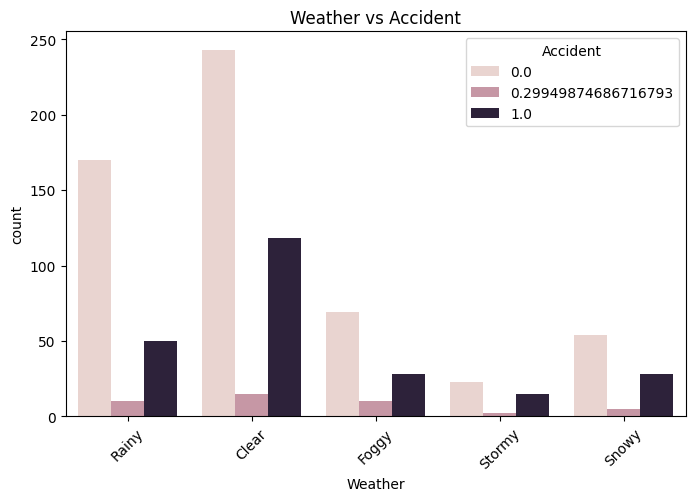

In [28]:
if 'Weather' in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(x='Weather', hue='Accident', data=df)
    plt.xticks(rotation=45)
    plt.title("Weather vs Accident")
    plt.show()

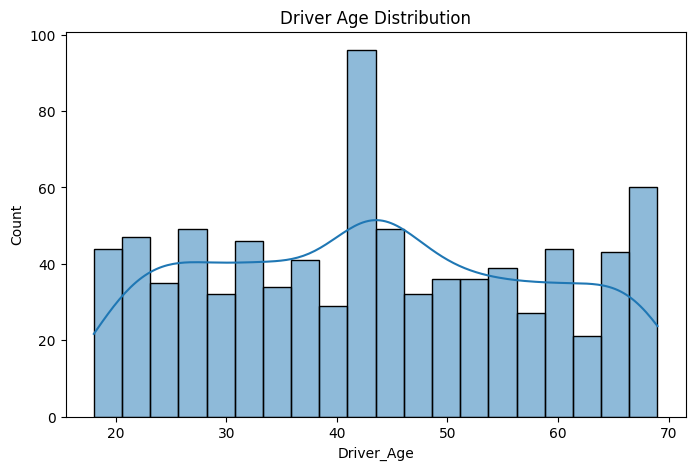

In [29]:
if 'Driver_Age' in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df['Driver_Age'], bins=20, kde=True)
    plt.title("Driver Age Distribution")
    plt.show()

In [30]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [31]:
X = df.drop('Accident', axis=1)
y = df['Accident']

In [37]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [38]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [39]:
y_pred = model.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.7083333333333334


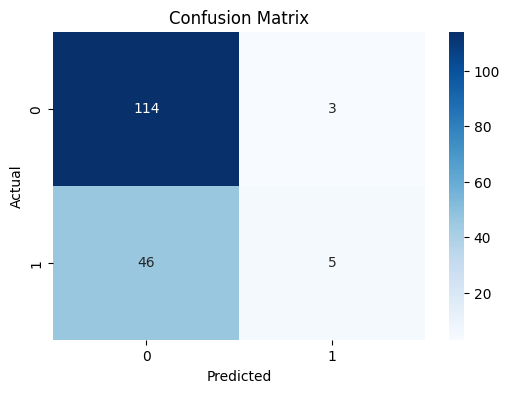

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.97      0.82       117
           1       0.62      0.10      0.17        51

    accuracy                           0.71       168
   macro avg       0.67      0.54      0.50       168
weighted avg       0.69      0.71      0.62       168



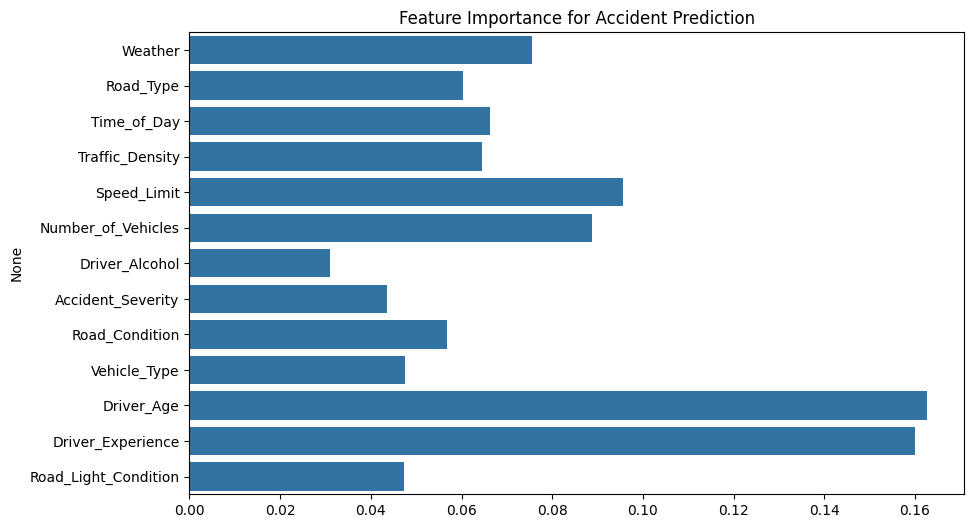

In [43]:
importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importance, y=features)

plt.title("Feature Importance for Accident Prediction")
plt.show()

In [44]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7083333333333334
